# GRIB: Interpolating from hybrid to height levels

This notebook demonstrates how to interpolate GRIB fieldlist data on hybrid model levels to height levels. Fieldlist support requires the usage of earthkit-data.

In [1]:
import earthkit.data as ekd
import numpy as np

import earthkit.meteo.vertical.fieldlist as vertical

## Hybrid levels

## Getting the data

The input is GRIB data on 137 IFS model levels for one step. We fetch the file and extract temperature, specific humidity, the surface geopotential and the surface pressure.

In [2]:
# fl = ekd.from_source("file", "/Users/cgr/metview/python_test/earthkit_data/meteo/blh.grib").to_fieldlist()[0]
# blh.ls()

fl = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-meteo/test-data/tq_ml137.grib2",
).to_fieldlist()

# LNSP → surface pressure [Pa]
lnsp = fl.sel({"parameter.variable": "lnsp", "vertical.level": 1})[0]
sp = lnsp.set(values=np.exp(lnsp.values))

t = fl.sel({"parameter.variable": "t"})  # temperature, 137 levels
q = fl.sel({"parameter.variable": "q"})  # specific humidity, 137 levels
zs = fl.sel({"parameter.variable": "z", "vertical.level": 1})[0]  # surface geopotential

t.head()

tq_ml137.grib2:   0%|          | 0.00/388k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1,hybrid,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,2,hybrid,None,regular_ll
2,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,3,hybrid,None,regular_ll
3,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,4,hybrid,None,regular_ll
4,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5,hybrid,None,regular_ll


The A and B coefficients defining the hybrid levels are embedded in the GRIB metadata and are inferred automatically.

## Using interpolate_hybrid_to_height_levels

### Geometric height above the ground

In [3]:
target_h = [1000.0, 5000.0]  # geometric height (m), above the ground

t_res = vertical.interpolate_hybrid_to_height_levels(
    t,  # data to interpolate
    target_h,
    t,  # temperature for height computation
    q,  # specific humidity for height computation
    zs,  # surface geopotential
    sp,  # surface pressure
    h_type="geometric",
    h_reference="ground",
    interpolation="linear",
)
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [4]:
# the first 2 values from the resulting fields
t_res.values[:, :2]

array([[281.85412384, 280.08061538],
       [261.09944397, 257.40889196]])

### Geometric height above sea level

In [5]:
target_h_sea = [1000.0, 5000.0]  # geometric height (m), above sea level

t_res_sea = vertical.interpolate_hybrid_to_height_levels(
    t,
    target_h_sea,
    t,
    q,
    zs,
    sp,
    h_type="geometric",
    h_reference="sea",
    interpolation="linear",
)
t_res_sea.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_mean_sea_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_mean_sea_level,None,regular_ll


In [6]:
# the first 2 values from the resulting fields
t_res_sea.values[:, :2]

array([[281.42654577, 280.26545729],
       [260.57936549, 257.59190812]])

### Geopotential height above the ground

In [7]:
target_h_gp = [1000.0, 5000.0]  # geopotential height (m), above the ground

t_res_gp = vertical.interpolate_hybrid_to_height_levels(
    t,
    target_h_gp,
    t,
    q,
    zs,
    sp,
    h_type="geopotential",
    h_reference="ground",
    interpolation="linear",
)
t_res_gp.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [8]:
# the first 2 values from the resulting fields
t_res_gp.values[:, :2]

array([[281.85343918, 280.07956803],
       [261.07536307, 257.38296683]])

### Using a subset of levels

It is possible to use only a **subset of the model levels** in the input data. This can significantly speed up the computations and reduce memory usage.

The model level range must be contiguous and include the bottom-most level. The example below uses only the 50 lowest model levels.

In [9]:
# keep only the 50 lowest model levels
t_sub = t.sel({"vertical.level": list(range(88, 138))})
q_sub = q.sel({"vertical.level": list(range(88, 138))})

t_res_sub = vertical.interpolate_hybrid_to_height_levels(
    t_sub,
    target_h,
    t_sub,
    q_sub,
    zs,
    sp,
    h_type="geometric",
    h_reference="ground",
    interpolation="linear",
)
t_res_sub.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000.0,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000.0,height_above_ground_level,None,regular_ll


In [10]:
# the first 2 values from the resulting fields
t_res_gp.values[:, :2]

array([[281.85343918, 280.07956803],
       [261.07536307, 257.38296683]])

### Using aux levels

The lowest (full) model level is always above the surface. Interpolation to a height between the surface and the lowest model level therefore returns NaN. We can compute the height of the lowest model level to see this gap:

In [11]:
t_bot = t.sel({"vertical.level": [137]})
q_bot = q.sel({"vertical.level": [137]})

h_bottom = vertical.height_on_hybrid_levels(t_bot, q_bot, zs, sp, h_type="geometric", h_reference="ground")

# the height of the first 2 gridpoints (m)
h_bottom.values[:, :2]

array([[ 9.91779623, 10.03333935]])

The lowest model level is approximately 10 m above the ground in the gridpoints we checked. Interpolating to 2 m therefore returns NaN:

In [12]:
target_h_near = [2.0]  # m above the ground

t_res_nan = vertical.interpolate_hybrid_to_height_levels(
    t,
    target_h_near,
    t,
    q,
    zs,
    sp,
    h_type="geometric",
    h_reference="ground",
    interpolation="linear",
)

# the first 2 values from the resulting fields
t_res_nan.values[:, :2]

array([[nan, nan]])

To overcome this problem we can supply auxiliary data via the `aux_bottom_h` and  `aux_bottom_data` kwargs. Both can be a single value (constant) or a field. The example below simply set the temperature at height 0 m (the surface) to slightly higher than at the lowest model level.

In [13]:
t_res_aux = vertical.interpolate_hybrid_to_height_levels(
    t,
    target_h_near,
    t,
    q,
    zs,
    sp,
    h_type="geometric",
    h_reference="ground",
    aux_bottom_h=0.0,  # m — height of the auxiliary level (surface)
    aux_bottom_data=t[-1] + 1.0,  # K — set field as temperature at the surface
    interpolation="linear",
)

# the first 2 values from the resulting fields
t_res_aux.values[:, :2]

array([[285.246615 , 288.5477654]])

In [21]:
blh = ekd.from_source("file", "/Users/cgr/metview/python_test/earthkit_data/meteo/blh.grib").to_fieldlist()[0]
blh.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,blh,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,0,surface,0,regular_ll


In [25]:
t_res_blh = vertical.interpolate_hybrid_to_height_levels(
    t,
    blh,
    t,
    q,
    zs=zs,
    sp=sp,
    h_type="geopotential",
    h_reference="ground",
    interpolation="linear",
)
t_res_blh.ls()

ValueError: When values and target_p have different shapes, target_p must be a scalar or a 1D array.

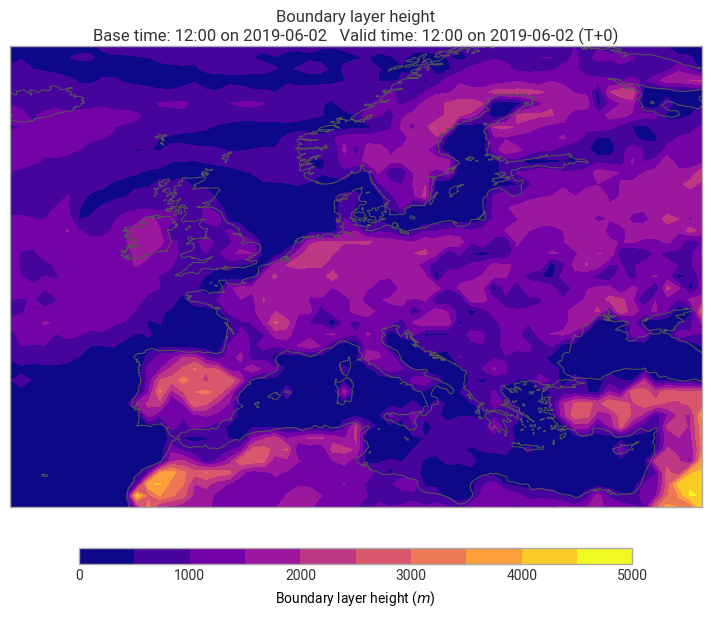

In [22]:
import earthkit.plots as ekp

ekp.quickplot(blh)

## Writing to GRIB

In [14]:
t_res.to_target("file", "_hybrid_to_hl.grib")

# read back and verify
t_res_saved = ekd.from_source("file", "_hybrid_to_hl.grib").to_fieldlist()
t_res_saved.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1000,height_above_ground_level,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5000,height_above_ground_level,None,regular_ll


In [15]:
t_res_saved.values[:, :2]

array([[281.85430908, 280.08087158],
       [261.09992981, 257.40852356]])